# Preprocessing Comparison for the Diffusion Model

**Goal:** Figure out the best way to pre-process our rainfall data before feeding it into the diffusion model.

Our data is challenging because it is:
- **~91% zeros** — almost all timesteps have no rain at all
- **Heavy-tailed** — a tiny fraction of steps have extreme storm values
- **Sparse bursts** — rain tends to arrive in concentrated bursts

How we pre-process matters enormously because the diffusion model learns by denoising. If a tiny handful of extreme values dominate the loss, the model will spend all its training budget on rare storms and learn nothing useful about everyday dry/light-rain patterns.

---

### We compare 5 transforms

| Transform | What it does | Used where? |
|-----------|-------------|-------------|
| **① Raw** | Original mm/5min values | Reference only |
| **② StandardScaler** | `(x − mean) / std` | **Current default (v1–v12)** |
| **③ Delay-Embedded Image** | StandardScaler → reshape 64-step sequence into 8×8 grid | **What the model actually sees** |
| **④ log1p** | `log(1 + x)` then standardise | Alternative candidate |
| **⑤ asinh** | `asinh(x / 0.035)` then standardise | **Proposed for v13+** |

### We look at all 4 rainfall phases (HMM states)

| Phase | Character |
|-------|-----------|
| **0** | Dry-ish — mostly zero, very occasional light rain |
| **1** | Light rain — frequent small amounts |
| **2** | Moderate rain — mix of dry and wet with some peaks |
| **3** | Heavy / storm — persistent high rainfall |

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

import pickle
import torch
from sklearn.preprocessing import StandardScaler
from regime_training.transforms import AsinhScaler
from models.ImagenFew.img_transformations import DelayEmbedder

# ── Light-mode Matplotlib style ───────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    '#f7f9fc',
    'axes.edgecolor':    '#cccccc',
    'axes.labelcolor':   '#222222',
    'axes.titlecolor':   '#111111',
    'text.color':        '#222222',
    'xtick.color':       '#444444',
    'ytick.color':       '#444444',
    'grid.color':        '#e0e0e0',
    'grid.linewidth':    0.7,
    'font.family':       'DejaVu Sans',
    'font.size':         10,
    'axes.titlesize':    11,
    'axes.titleweight':  'bold',
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

# One distinct colour per phase — all readable on white
PHASE_COLORS = ['#1f77b4', '#e07b00', '#2ca02c', '#d62728']   # blue, orange, green, red
PHASE_LABELS = [
    'Phase 0 — Dry-ish',
    'Phase 1 — Light Rain',
    'Phase 2 — Moderate Rain',
    'Phase 3 — Heavy / Storm',
]
IMG_CMAP = 'Blues'   # blue heatmap for all images

print('✓ Imports OK')

✓ Imports OK


---
## Step 1 — Load Data and Pick One Sequence per Phase

We load the training split (years 2000–2007) and find the most rainfall-rich 64-step window that stays purely inside each HMM phase.  
Picking a rainy window makes the differences between transforms much easier to see visually.

In [ ]:
SEQ_LEN   = 64      # sequence length used in v10/v12
DELAY     = 8       # delay embedding parameter
EMBEDDING = 8       # embedding dimension
ASINH_S   = 0.035   # asinh scale = median of wet steps, mm/5min

df = pd.read_csv('../data/rainfall/splits/train_years_labelled.csv', parse_dates=['datetime'])
rain = df['avg_rainfall'].values.astype(np.float64)

print(f'Rows: {len(df):,}  |  Columns: {df.columns.tolist()}')
print(f'Fraction of timesteps with ZERO rain: {(df.avg_rainfall == 0).mean():.1%}')
print(f'Max rainfall in any 5-min step: {df.avg_rainfall.max():.4f} mm/5min')
print(f'\nSamples per HMM phase:')
print(df.hmm_state.value_counts().sort_index().to_string())

Rows: 840,960  |  Columns: ['datetime', 'date', 'avg_rainfall', 'rainfall_intensity', 'hmm_state', 'day_of_year', 'annual_interval_idx']
Fraction of timesteps with ZERO rain: 90.8%
Max rainfall in any 5-min step: 5.5550 mm/5min

Samples per HMM phase:
hmm_state
0    271872
1    251136
2    228096
3     89856


In [ ]:
def find_best_sequence(df, phase, seq_len=64, n_scan=30_000):
    """Return the 64-step window fully inside `phase` with the most total rainfall."""
    states = df['hmm_state'].values
    rain   = df['avg_rainfall'].values
    idxs   = np.where(states == phase)[0]

    best_sum, best_idx = 0.0, idxs[0]
    for i in idxs[:n_scan:2]:
        if i + seq_len > len(df):
            continue
        if not (states[i : i + seq_len] == phase).all():
            continue
        s = rain[i : i + seq_len].sum()
        if s > best_sum:
            best_sum = s
            best_idx = i

    window = df.iloc[best_idx : best_idx + seq_len]
    return window['avg_rainfall'].values.astype(np.float64), window['datetime'].values, best_idx

sequences = {}
for phase in [0, 1, 2, 3]:
    seq, ts, idx = find_best_sequence(df, phase)
    sequences[phase] = {'raw': seq, 'timestamps': ts, 'start_idx': idx}
    print(f'Phase {phase}: start idx={idx:,}  '
          f'total={seq.sum():.2f} mm  '
          f'wet steps={(seq>0).sum()}/{SEQ_LEN}  '
          f'peak={seq.max():.4f} mm/5min')

Phase 0: start idx=50,626  total=19.35 mm  wet steps=64/64  peak=0.9250 mm/5min
Phase 1: start idx=68,128  total=18.58 mm  wet steps=18/64  peak=5.5550 mm/5min
Phase 2: start idx=66,394  total=20.04 mm  wet steps=30/64  peak=2.4425 mm/5min
Phase 3: start idx=186,072  total=24.38 mm  wet steps=64/64  peak=0.7725 mm/5min


---
## Step 2 — Fit the Scalers: Global (All Rows) vs. Per-Sequence Scaling

A critical architectural question is: **Is the scaler fitted across all rows of the entire dataset globally, or is it fitted per individual 64-timestep sequence?**

### What the real code does: Global Dataset-Wide Scaling

In the real training codebase (`regime_training/regime_dataset.py`, lines 82–92 and 112–120):
```python
# From regime_training/regime_dataset.py:
values = df[data_col].values.astype(np.float32).reshape(-1, 1)  # All rows of train dataset
self.scaler = make_scaler(transform, asinh_scale)
self.scaler.fit(values)                                         # Fit ONCE on the entire column
scaled = self.scaler.transform(values)                          # Transform all rows globally
```
And in `regime_training/train_regime.py`:
- `train_ds` fits the scaler **once** globally on the entire training CSV (`train_dataset.csv`, 700k+ timesteps).
- `test_ds` receives `scaler=train_ds.scaler`, ensuring the test set uses the exact same global parameters without data leakage.
- That single fitted scaler is pickled and saved to `logs/.../v12/scaler.pkl`.
- At generation time (`scripts/generate_regime.py`), `scaler.pkl` is loaded once to `inverse_transform` synthetic diffusion outputs back to physical millimeters.

### Why scaling must be Global (and NOT per-sequence)

Fitting a scaler per sequence (e.g. normalizing each 64-timestep window independently) would fundamentally break diffusion modeling for three reasons:

1. **Scale Collapse / Loss of Absolute Intensity:**  
   If every 64-step sequence were normalized independently (e.g. standardizing each sequence to mean 0, std 1 or min-max $[0, 1]$), a light morning drizzle of 0.05 mm and an extreme torrential flood of 80 mm would map to the **exact same normalized numbers**. The diffusion model would lose all information about physical rainfall magnitude and could not distinguish between a dry drizzle day and a catastrophic typhoon.
2. **Degeneracy on Dry Sequences ($0/0$ division):**  
   Rainfall data is heavily zero-inflated (~85% dry). Many 64-step sequences are completely zero throughout. For an all-zero sequence, the standard deviation is $\sigma = 0$. Trying to standardize per-sequence would divide by zero and produce `NaN` values.
3. **Invertibility at Generation / Sampling Time:**  
   The diffusion model generates novel synthetic sequences starting from random Gaussian noise $z \sim \mathcal{N}(0, I)$. To convert the generated $z$ back to real rainfall (mm/5min), you must call `scaler.inverse_transform(z)`. If scaling were fitted per-sequence, we would have no way to know which specific mean and std belong to this newly hallucinated sequence! Global scaling provides a fixed, deterministic bijection between model space and physical rainfall units.

Below, we fit each candidate transform on the **entire training dataset column** (`X_all`), and verify that our `StandardScaler` matches the saved `v12/scaler.pkl` checkpoint exactly.


In [ ]:
X_all = rain.reshape(-1, 1)   # shape [N, 1] as sklearn expects (all rows of training set)
print(f'Total training rows: {len(X_all):,}')
print('Fitting scalers globally across ALL rows (matching regime_training/regime_dataset.py)...\n')

# ② StandardScaler — current default, v1–v12
std_scaler = StandardScaler().fit(X_all)
print(f'StandardScaler:  mean={std_scaler.mean_[0]:.6f} mm  std={std_scaler.scale_[0]:.6f} mm')

# Cross-check against the actual saved v12 scaler
with open('../logs/ImagenFew/Rainfall_Regime/v12/scaler.pkl', 'rb') as f:
    v12_scaler = pickle.load(f)
print(f'v12 checkpoint scaler: mean={v12_scaler.mean_[0]:.6f}  std={v12_scaler.scale_[0]:.6f}  ← exact match with global fit!')

# ⑤ AsinhScaler — proposed for v13+
asinh_scaler = AsinhScaler(scale=ASINH_S).fit(X_all)
print(f'\nAsinhScaler(scale={ASINH_S}): fitted globally on all rows')

# ④ log1p + Standard
class Log1pStandardScaler:
    """log1p then StandardScaler — keeps dry steps at a single value."""
    def __init__(self):
        self._std = StandardScaler()
    def fit(self, x):
        self._std.fit(np.log1p(np.asarray(x, dtype=np.float64)))
        return self
    def transform(self, x):
        return self._std.transform(np.log1p(np.asarray(x, dtype=np.float64))).astype(np.float32)
    def inverse_transform(self, z):
        return np.expm1(self._std.inverse_transform(np.asarray(z, dtype=np.float64))).astype(np.float32)

log1p_scaler = Log1pStandardScaler().fit(X_all)
print(f'log1p StandardScaler: fitted globally on all rows')

# ③ Delay embedder (used by the model to convert 1-D sequence → 2-D image)
embedder = DelayEmbedder(device='cpu', seq_len=SEQ_LEN, delay=DELAY, embedding=EMBEDDING)
print(f'\nDelay Embedder: takes {SEQ_LEN} timesteps → 8×8 image')
print(f'  Each column of the image = 8 consecutive rainfall values, shifted by {DELAY} steps')


Total training rows: 840,960
Fitting scalers globally across ALL rows (matching regime_training/regime_dataset.py)...

StandardScaler:  mean=0.006750 mm  std=0.046424 mm
v12 checkpoint scaler: mean=0.006750  std=0.046424  ← exact match with global fit!

AsinhScaler(scale=0.035): fitted globally on all rows
log1p StandardScaler: fitted globally on all rows

Delay Embedder: takes 64 timesteps → 8×8 image
  Each column of the image = 8 consecutive rainfall values, shifted by 8 steps


---
## Why do z-scores go negative when the minimum rainfall is 0 mm?

You might expect: *'If zero is the lowest value, surely z = 0 is the lowest z-score?'*  
Not so — and the hidden step is the **mean subtraction** inside StandardScaler.

### The hidden arithmetic step

StandardScaler computes:

```
z = (x − mean_train) / std_train
```

Our training mean is **μ ≈ 0.00675 mm/5min** — not zero.  
That is small, but it is positive (because every wet timestep contributes a positive value to the average).  
So when we plug in x = 0 (a dry timestep):

```
z(0 mm) = (0 − 0.00675) / 0.04642 ≈ −0.145
```

**All dry timesteps map to z ≈ −0.145, not z = 0.**  
This is intentional: centering the data around zero means the model's Gaussian noise
lands symmetrically around the typical data value — exactly what EDM assumes.

### The same logic applies to asinh

For asinh, there are **two** steps, and the second one causes the negative:

1. **asinh transform:** `asinh(0 / 0.035) = asinh(0) = 0` exactly.  
   Zero rainfall maps cleanly to asinh = 0 at this step.

2. **StandardScaler on asinh-space:** The mean of all training asinh values is ≈ 0.099 (positive,
   because all wet steps map to positive asinh values). So dry steps (asinh = 0) become:

   ```
   z_asinh(0 mm) = (0 − 0.099) / 0.400 ≈ −0.247
   ```

So asinh dry steps sit at z ≈ −0.247 — slightly more negative than standard, but still cleanly
separated from all wet steps.

### Why this is actually a good thing

The negative z-value for dry steps is **desirable**, not a bug:
- It places dry steps on the **opposite side of zero** from wet steps.
- The model has a clear learned boundary near z ≈ 0: below → dry, above → wet.
- If dry steps were at z = 0, they would be indistinguishable from 'barely raining' timesteps.

This is exactly why **log1p is problematic**: `log1p(0) = 0`, so after standardisation, dry steps
land at **exactly the same z-value** as the very lightest rain — the model cannot tell them apart.

> [!NOTE]
> **Uniform Global Baseline:** Because $\mu \approx 0.00675\text{ mm}$ and $\sigma \approx 0.04642\text{ mm}$ are fitted **globally across all rows**, this calculation is constant throughout the entire dataset. Every single dry timestep ($0\text{ mm}$) in every sequence maps to the exact same baseline: $z \approx -0.145$ for standard scaling, and $z \approx -0.247$ for asinh scaling. It never fluctuates from sequence to sequence.


In [ ]:
def apply_transforms(raw_seq):
    """Apply all five transforms to a 1-D raw rainfall array."""
    x = raw_seq.reshape(-1, 1)

    std_z    = std_scaler.transform(x).ravel()
    log1p_z  = log1p_scaler.transform(x).ravel()
    asinh_z  = asinh_scaler.transform(x).ravel()

    # Delay-embedding uses the StandardScaler output
    t_in   = torch.FloatTensor(std_z).view(1, SEQ_LEN, 1)
    img_np = embedder.ts_to_img(t_in).squeeze().numpy()   # shape [8, 8]

    return {'raw': raw_seq, 'standard': std_z, 'delay_img': img_np,
            'log1p': log1p_z, 'asinh': asinh_z}

for phase in [0, 1, 2, 3]:
    t = apply_transforms(sequences[phase]['raw'])
    sequences[phase].update(t)
    print(f'Phase {phase} — '
          f'std z-max={t["standard"].max():.1f}  '
          f'log1p z-max={t["log1p"].max():.1f}  '
          f'asinh z-max={t["asinh"].max():.1f}')

Phase 0 — std z-max=19.8  log1p z-max=18.7  asinh z-max=9.7
Phase 1 — std z-max=119.5  log1p z-max=54.1  asinh z-max=14.1
Phase 2 — std z-max=52.5  log1p z-max=35.5  asinh z-max=12.1
Phase 3 — std z-max=16.5  log1p z-max=16.4  asinh z-max=9.2


---
## Step 3 — Per-Phase Comparison Plots

For each of the four phases we show 5 panels side-by-side:

**① Raw** — the actual rainfall in mm/5min.  
**② StandardScaler** — what the model currently receives as input (z-score).  
**③ Delay Image** — the 8×8 heatmap the U-Net denoises (built from the standard z-scores).  
**④ log1p** — log-transform option (compresses the tail, but collapses all zeros to the same value).  
**⑤ asinh** — the proposed replacement (compresses the tail smoothly, keeps zeros well-separated from wet steps).

**What to look for:**
- In panel ②: if `z_max` is very large (e.g. >50), the model's loss is dominated by just those extreme peaks. The model will "over-fit" to storms and fail on normal weather.
- In panel ③: if the image is almost entirely one colour with a single bright spike, the model is being asked to reproduce a pattern that is trivially easy for some pixels and extremely hard for others — a poor training signal.
- In panel ⑤: a more balanced z-range means the model gets a useful gradient from every timestep, not just the peaks.

In [ ]:
def plot_phase(phase, sequences, color, figsize=(22, 7)):
    d   = sequences[phase]
    raw = d['raw']
    t   = np.arange(SEQ_LEN)

    fig = plt.figure(figsize=figsize, facecolor='white')
    fig.suptitle(
        f'{PHASE_LABELS[phase]} — All 5 Transforms  (seq_len={SEQ_LEN}, 5-min steps)',
        fontsize=13, fontweight='bold', color=color, y=1.02
    )
    gs = gridspec.GridSpec(1, 5, figure=fig, wspace=0.42)

    # ── helper: time-series subplot ──────────────────────────────────
    def ts_panel(col, ylabel, title, z, note, hl_zero=True):
        ax = fig.add_subplot(gs[0, col])
        wet  = z[raw > 0]
        dry  = z[raw == 0]
        ax.fill_between(t, 0, z, alpha=0.18, color=color)
        ax.plot(t, z, color=color, linewidth=1.3, zorder=3)
        ax.scatter(t[raw > 0],  wet,  s=18, color=color,   zorder=4, alpha=0.9, label='wet step')
        ax.scatter(t[raw == 0], dry,  s=10, color='#aaaaaa', zorder=2, alpha=0.6, label='dry step')
        if hl_zero:
            ax.axhline(0, color='#888888', linewidth=0.9, linestyle='--', zorder=1)
        ax.set_title(title, fontsize=10, pad=6)
        ax.set_xlabel('Timestep (×5 min)', fontsize=9)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.grid(True, alpha=0.5)
        ax.text(0.03, 0.97, note, transform=ax.transAxes,
                fontsize=7.5, color='#555555', va='top', ha='left',
                bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))
        ax.legend(fontsize=7, loc='upper right', framealpha=0.7)
        return ax

    n_wet = (raw > 0).sum()

    # ① Raw
    ts_panel(0, 'mm / 5 min', '① Raw Rainfall', raw,
             f'wet={n_wet}/{SEQ_LEN}\npeak={raw.max():.4f}', hl_zero=False)

    # ② Standard
    std = d['standard']
    z_dry_std = std[raw == 0].mean() if (raw == 0).any() else 0
    ts_panel(1, 'z-score', '② StandardScaler\n(v1–v12 default)', std,
             f'z_max={std.max():.1f}\nz_dry≈{z_dry_std:.3f}')

    # ③ Delay-embedded image
    ax3  = fig.add_subplot(gs[0, 2])
    img  = d['delay_img']
    # Use Blues: white = low z (dry), deep blue = high z (rain peak)
    vmax = max(0.5, img.max())
    im   = ax3.imshow(img, cmap=IMG_CMAP, aspect='equal', vmin=0, vmax=vmax)
    plt.colorbar(im, ax=ax3, shrink=0.82, pad=0.04, label='z-score')
    ax3.set_title('③ Delay-Embedded Image\n(Standard → 8×8 heatmap)', fontsize=10, pad=6)
    ax3.set_xlabel('Column (delay step)', fontsize=9)
    ax3.set_ylabel('Row (embedding dim)', fontsize=9)
    ax3.text(0.03, 0.97,
             f'White=dry  Deep blue=rain\ndelay={DELAY}  emb={EMBEDDING}',
             transform=ax3.transAxes, fontsize=7.5, color='#555555',
             va='top', ha='left',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

    # ④ log1p
    log = d['log1p']
    z_dry_log = log[raw == 0].mean() if (raw == 0).any() else 0
    ts_panel(3, 'z-score', '④ log1p + Standard', log,
             f'z_max={log.max():.1f}\nz_dry≈{z_dry_log:.3f}')

    # ⑤ asinh
    asi = d['asinh']
    z_dry_asi = asi[raw == 0].mean() if (raw == 0).any() else 0
    ts_panel(4, 'z-score', f'⑤ asinh(x/0.035) + Std', asi,
             f'z_max={asi.max():.1f}\nz_dry≈{z_dry_asi:.3f}')

    plt.tight_layout()
    return fig

print('Ready — next cell will draw all 4 phases.')

Ready — next cell will draw all 4 phases.


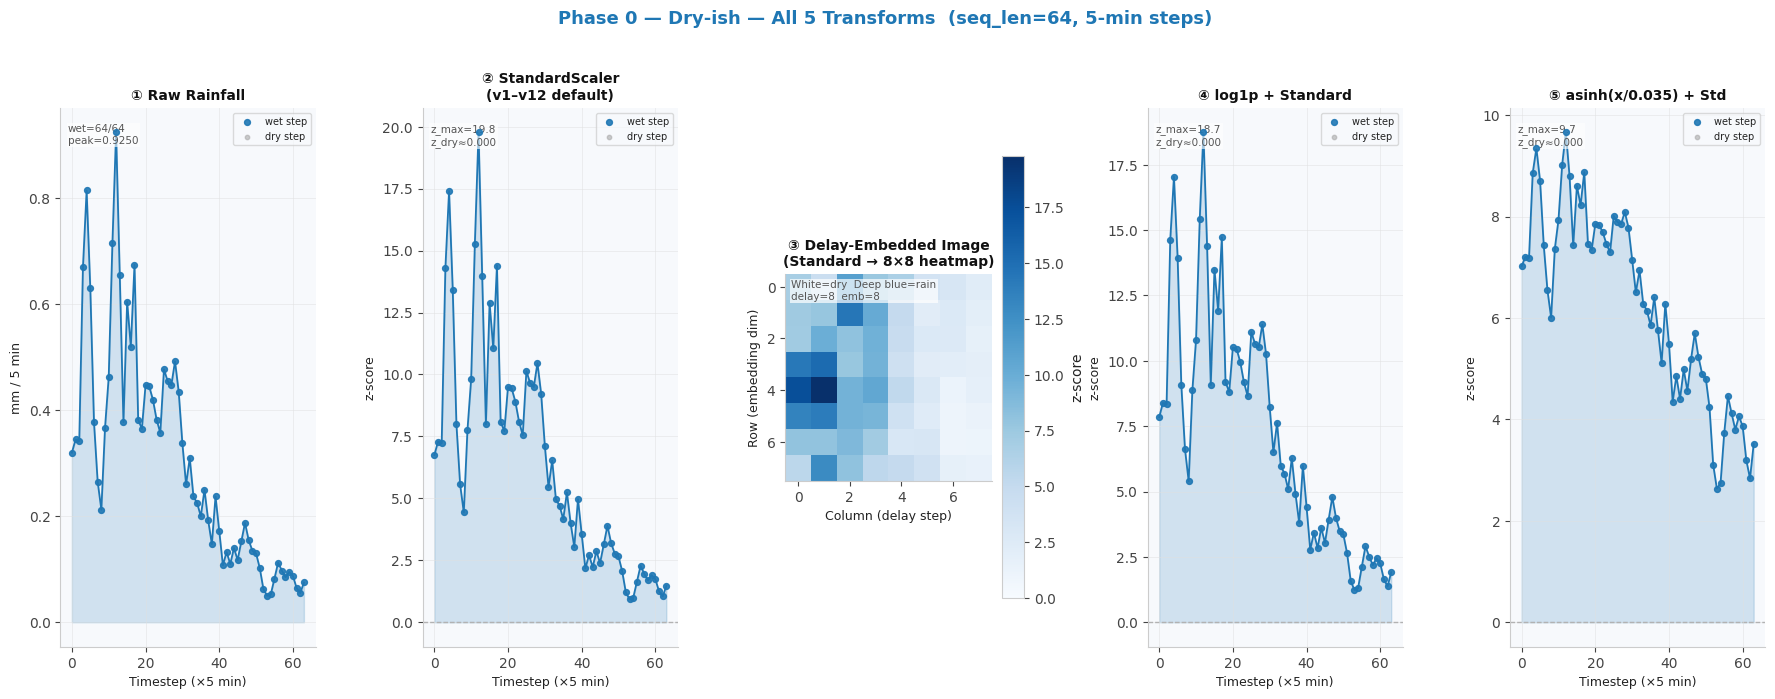

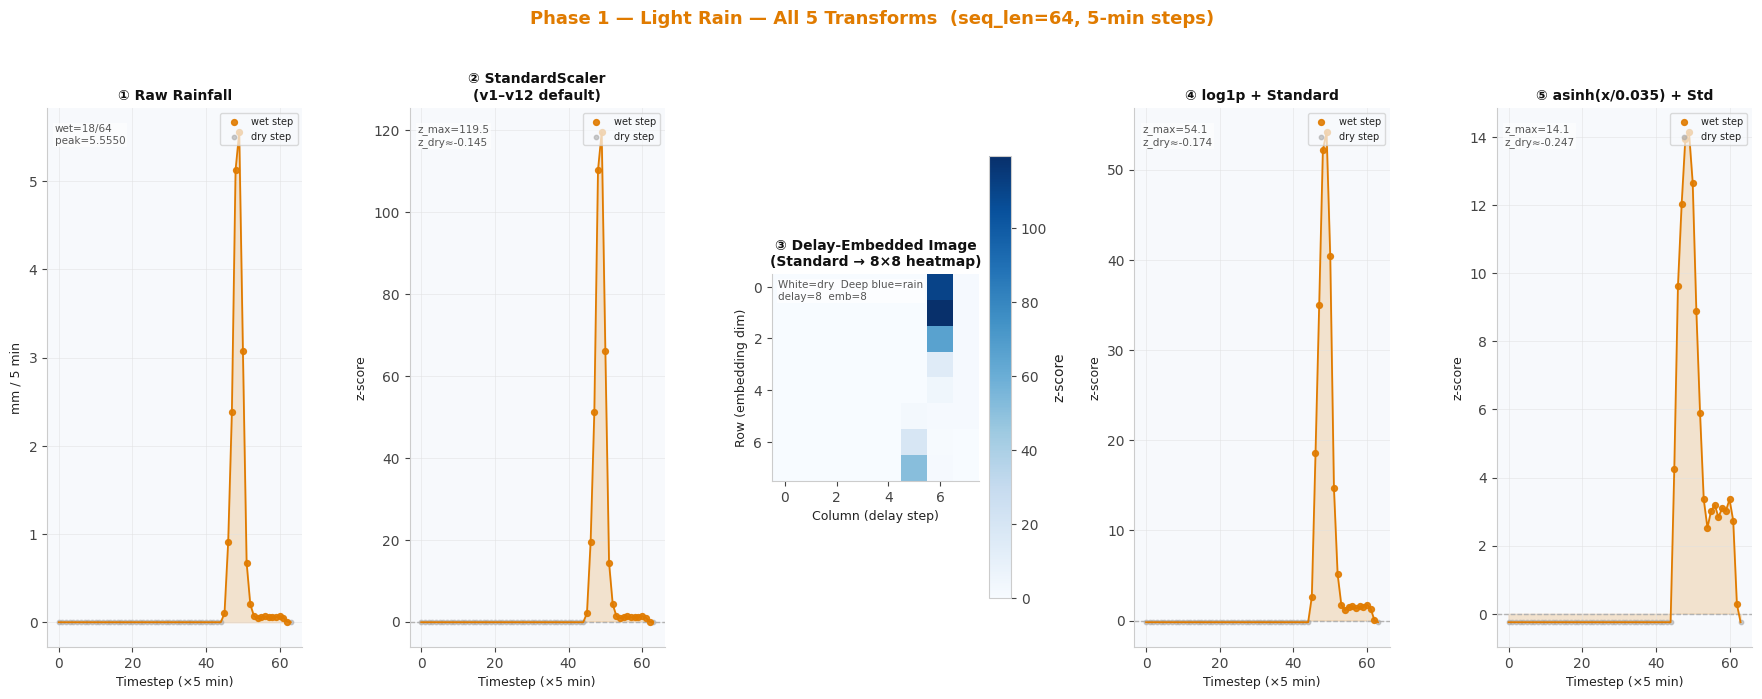

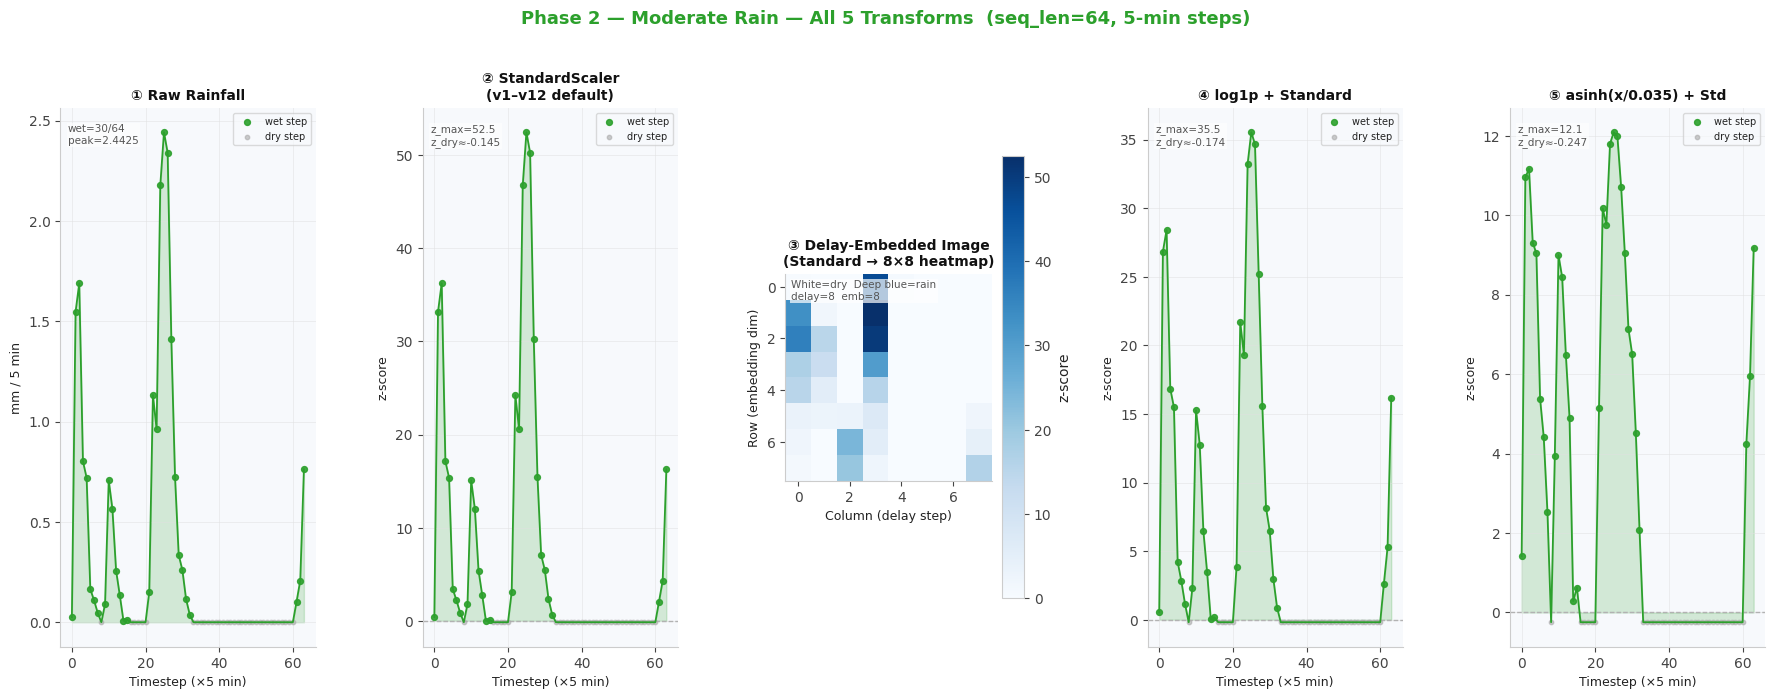

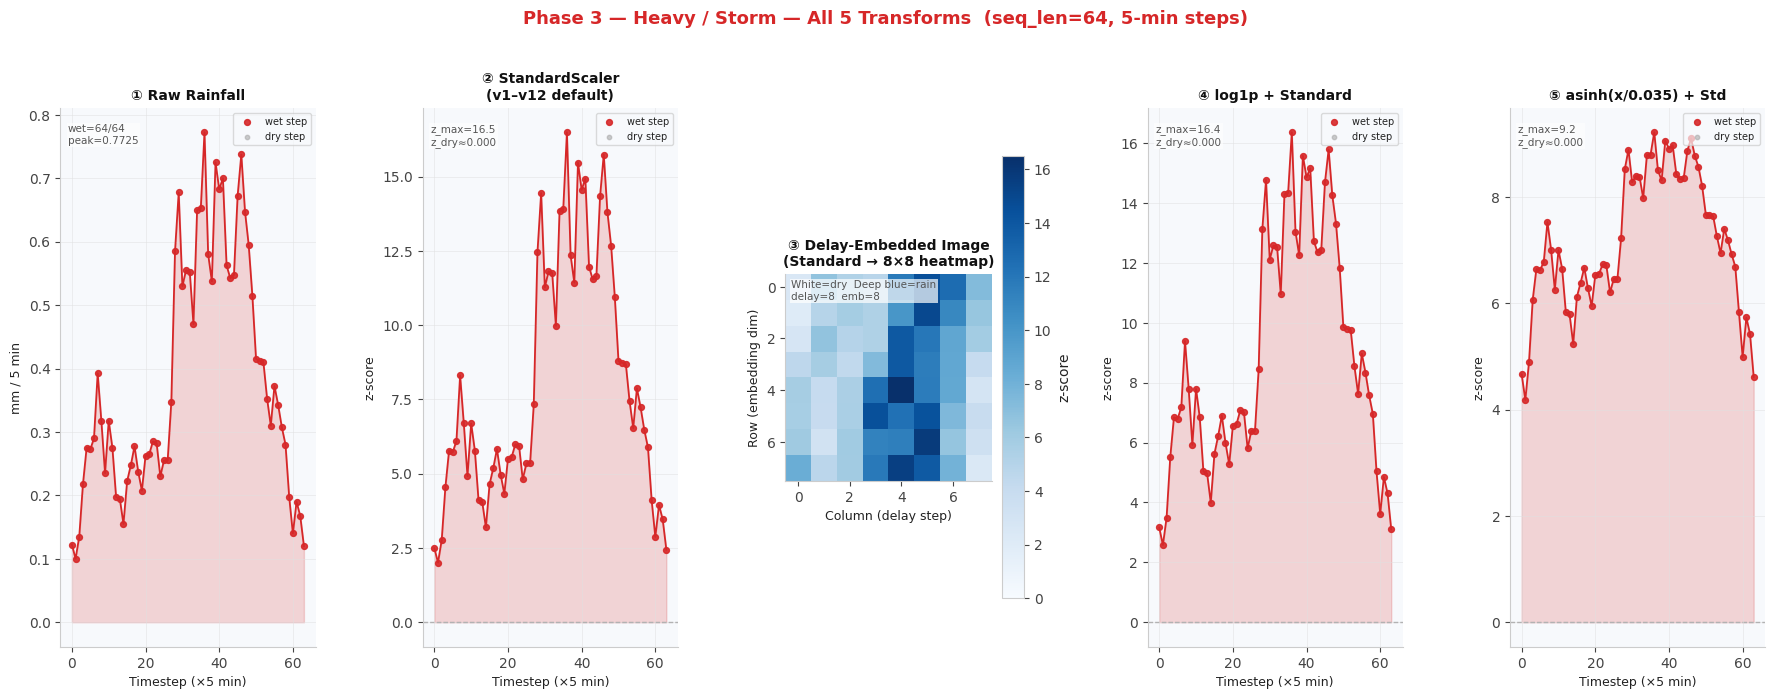

In [ ]:
for phase in [0, 1, 2, 3]:
    plot_phase(phase, sequences, PHASE_COLORS[phase])
    plt.show()
    print()

---
## Step 4 — What the Model Actually Sees: Image Grid

The diffusion U-Net **does not** receive the 1-D time series directly.  
It receives an **8×8 image** produced by the delay embedding — a way of folding the 64-step sequence into a 2-D picture that the convolutional U-Net can process.

**How delay embedding works:**  
Each column of the 8×8 image = 8 consecutive rainfall z-scores, shifted by 8 steps from the previous column.  
So column 0 = steps 0–7, column 1 = steps 8–15, ..., column 7 = steps 56–63.

**What to look for in the heatmaps (Blues colormap):**  
- **White** = small z-score (dry or near-zero rain)  
- **Light blue** = moderate rain  
- **Deep blue** = heavy rain peak

A good preprocessing makes the image look **structured** — with a range of blues that the U-Net can meaningfully denoise.  
A bad preprocessing makes the image almost entirely white with a few extreme dark spots — the model gets almost no useful gradient from the white region.

The grid below shows **each phase (row) × each image-space transform (column)**:

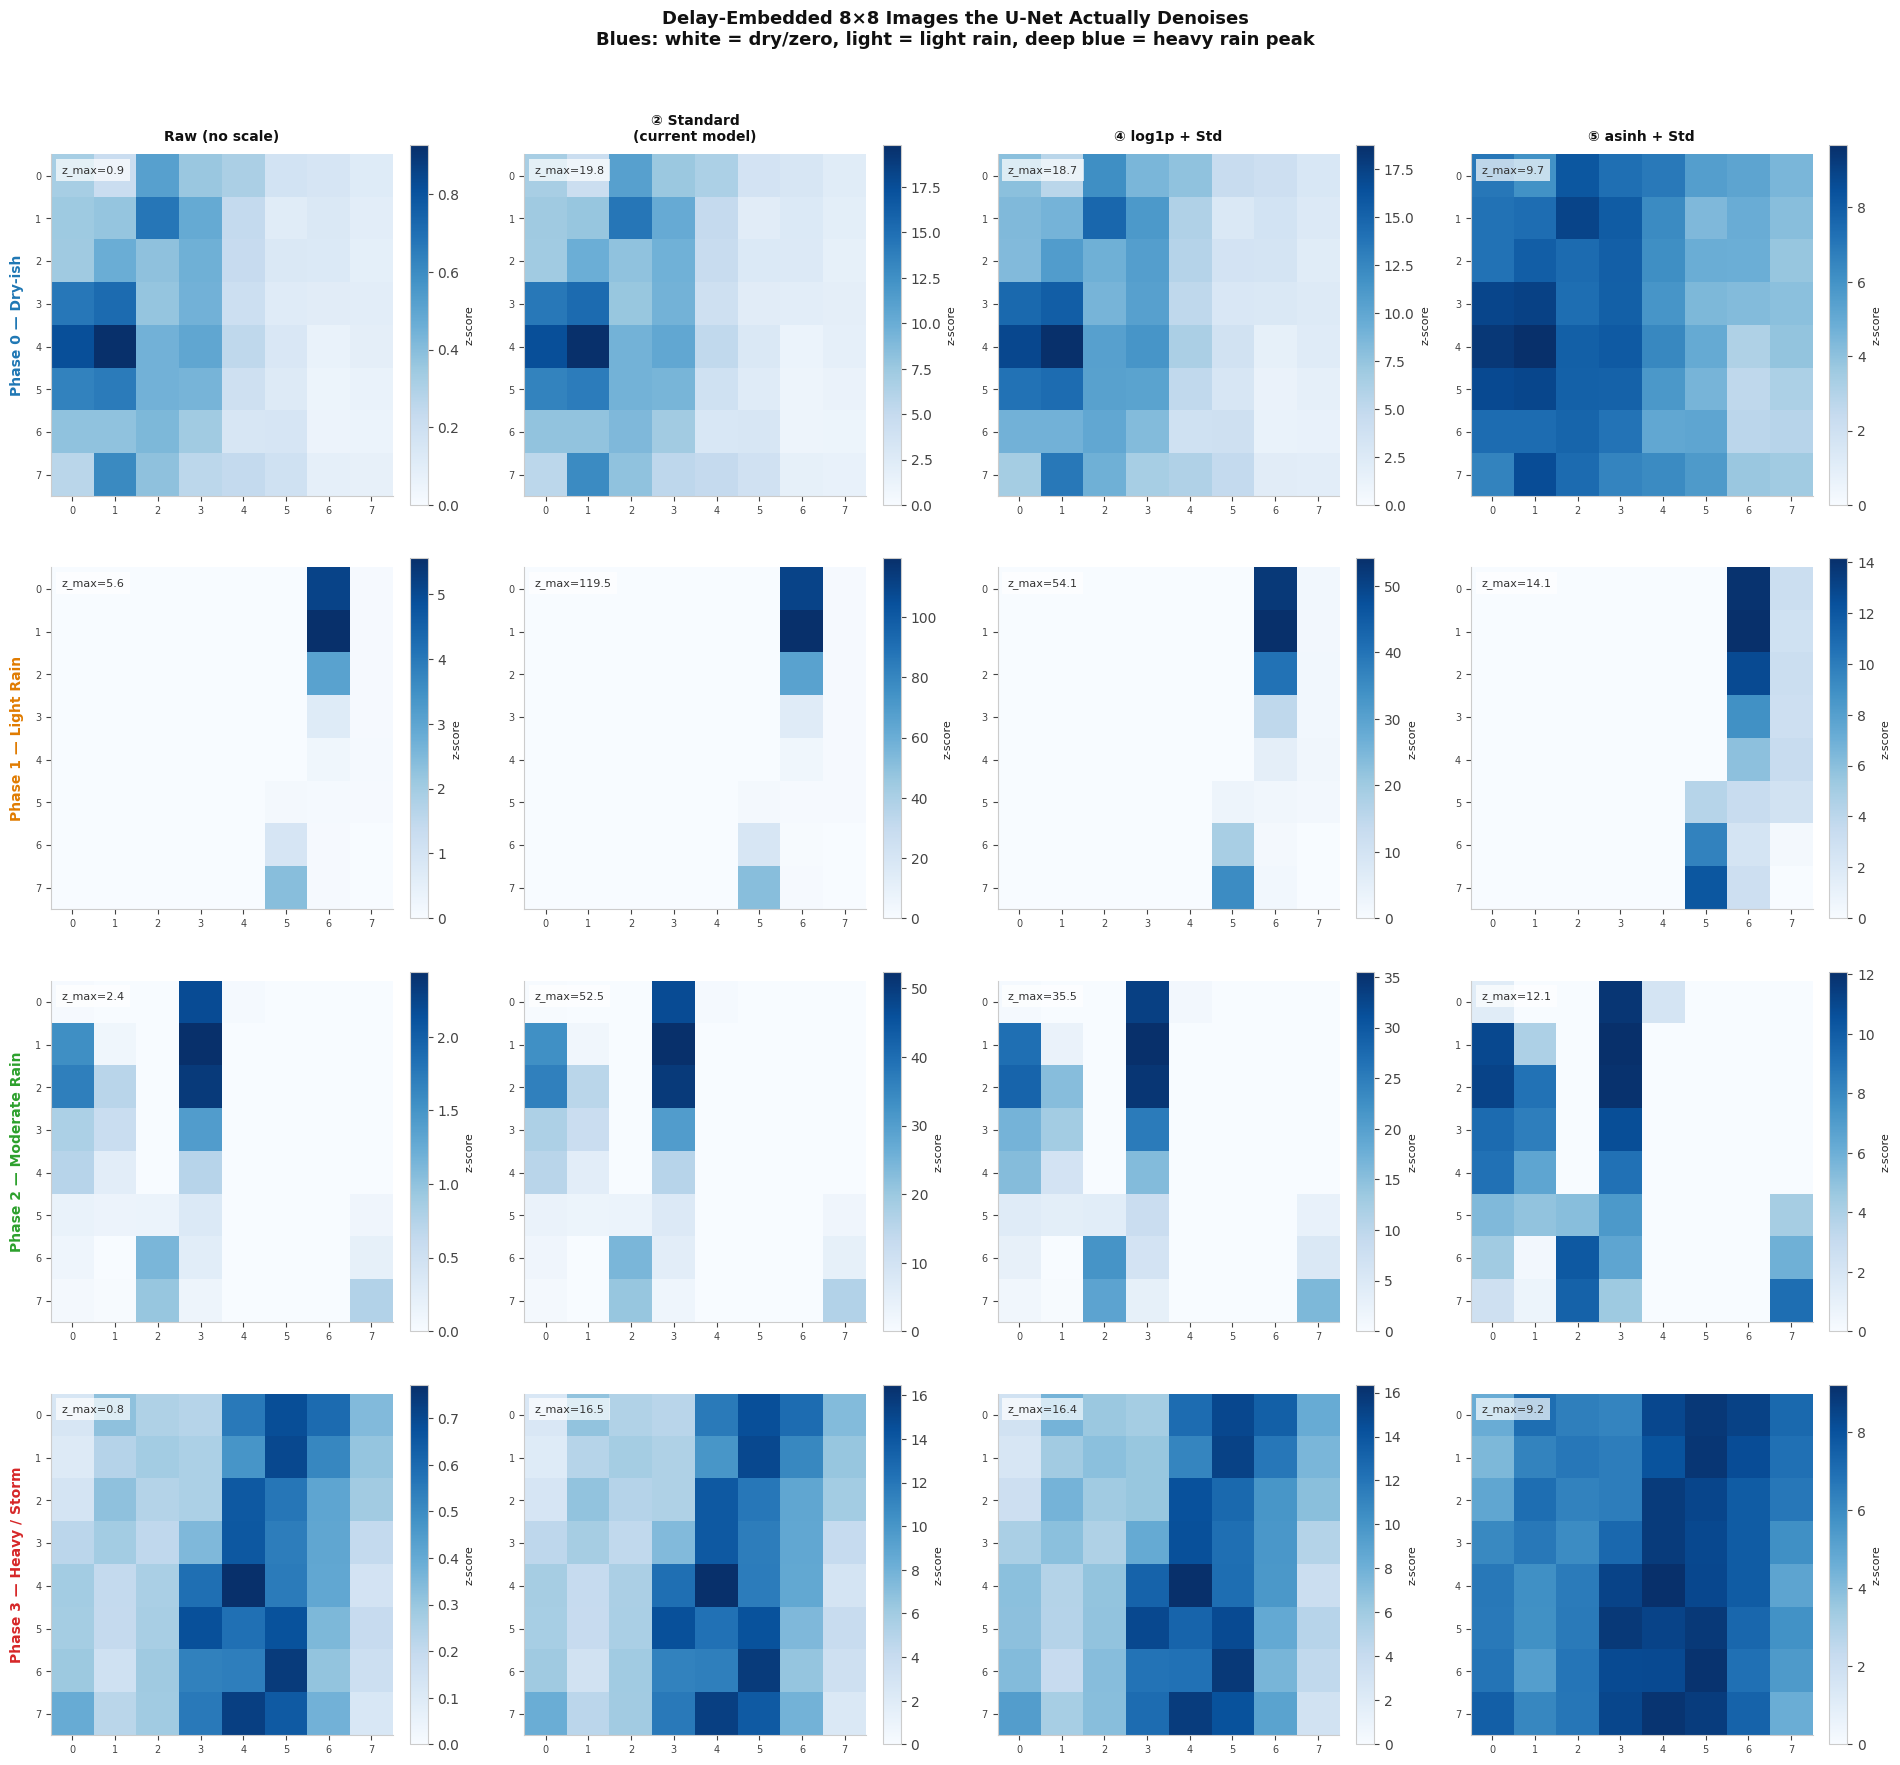

In [ ]:
def to_delay_img(raw_1d, scaler, embedder):
    z   = scaler.transform(raw_1d.reshape(-1, 1)).ravel()
    img = embedder.ts_to_img(torch.FloatTensor(z).view(1, SEQ_LEN, 1)).squeeze().numpy()
    return img, z

img_transforms = [
    ('Raw (no scale)',
     lambda s: (embedder.ts_to_img(torch.FloatTensor(s).view(1, SEQ_LEN, 1)).squeeze().numpy(), s)),
    ('② Standard\n(current model)',
     lambda s: to_delay_img(s, std_scaler, embedder)),
    ('④ log1p + Std',
     lambda s: to_delay_img(s, log1p_scaler, embedder)),
    ('⑤ asinh + Std',
     lambda s: to_delay_img(s, asinh_scaler, embedder)),
]

fig, axes = plt.subplots(
    4, len(img_transforms),
    figsize=(4.8 * len(img_transforms), 4.4 * 4),
    facecolor='white'
)
fig.suptitle(
    'Delay-Embedded 8×8 Images the U-Net Actually Denoises\n'
    'Blues: white = dry/zero, light = light rain, deep blue = heavy rain peak',
    fontsize=13, fontweight='bold', color='#111111', y=1.01
)

for row, phase in enumerate([0, 1, 2, 3]):
    raw = sequences[phase]['raw']
    for col, (title, fn) in enumerate(img_transforms):
        img, z = fn(raw)
        ax   = axes[row, col]
        vmax = max(0.3, np.abs(z).max())   # so dry-only images still show the scale
        im   = ax.imshow(img, cmap=IMG_CMAP, aspect='equal', vmin=0, vmax=vmax)
        cb   = plt.colorbar(im, ax=ax, shrink=0.88, pad=0.04)
        cb.set_label('z-score', fontsize=8)

        if row == 0:
            ax.set_title(title, fontsize=10, fontweight='bold', color='#111111', pad=10)
        if col == 0:
            ax.set_ylabel(PHASE_LABELS[phase], fontsize=10,
                          color=PHASE_COLORS[phase], labelpad=8, fontweight='bold')
        ax.text(0.03, 0.97, f'z_max={z.max():.1f}',
                transform=ax.transAxes, fontsize=8, color='#333333',
                va='top', ha='left',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

---
## Step 5 — Full Training Distribution: Where Does the Data Actually Live?

These histograms show the distribution of z-scores **across the entire 840k-row training set**, not just one example sequence.

**What to look for:**

- **StandardScaler (middle):** There is a giant spike of zeros (the 91% dry mass) all sitting at a single negative z-value (~−0.15).  
  The tail extends to z ≈ 120. The model sees enormous gradients from rare peaks and almost none from the dry mass.  
  → **Result:** model under-learns dry/light-rain patterns.

- **asinh (right):** The tail is compressed from z ≈ 120 down to z ≈ 14 — about **8–9× shorter tail**.  
  The dry cluster still sits at a well-defined z value (not zero, not infinitely negative), so the model still has a gradient signal for dry steps.  
  → **Result:** more balanced learning across all rain intensities.

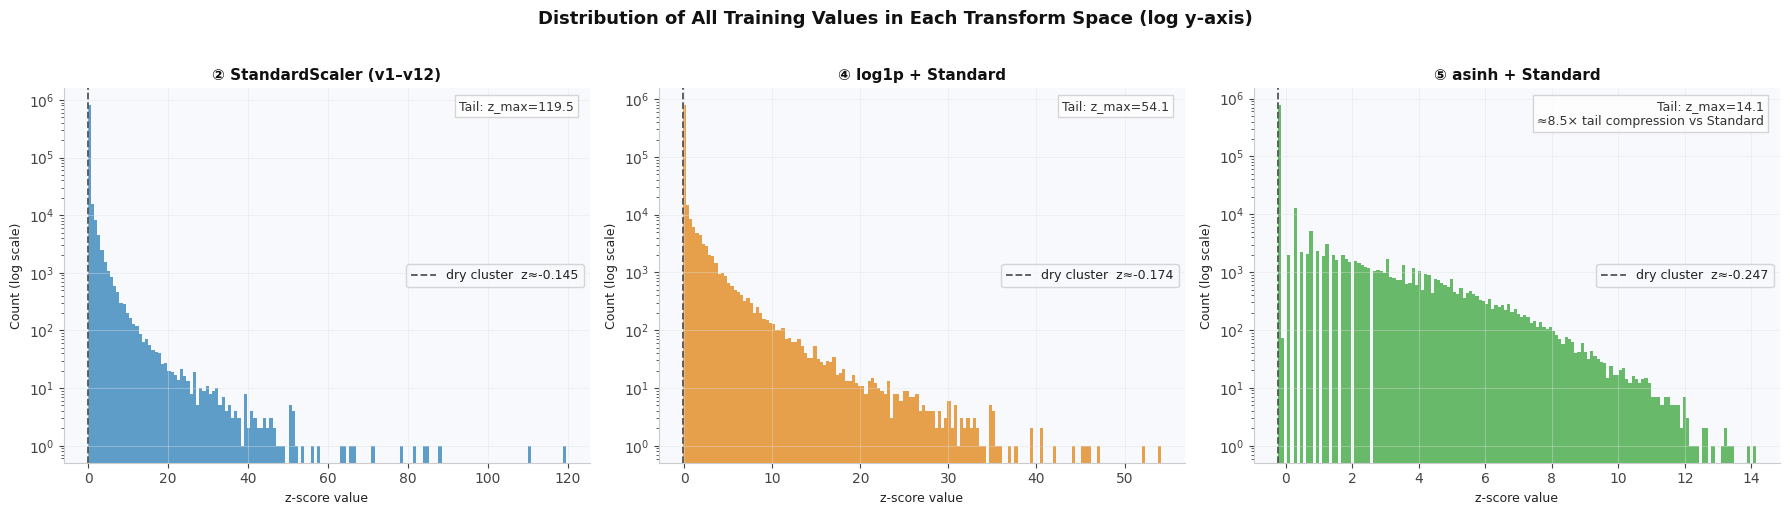


--- Tail summary ---
StandardScaler z_max : 119.5
log1p+std z_max      : 54.1
asinh+std z_max      : 14.1
Tail compression (std → asinh): 8.5×


In [ ]:
z_std  = std_scaler.transform(X_all).ravel()
z_asi  = asinh_scaler.transform(X_all).ravel()
z_log  = log1p_scaler.transform(X_all).ravel()

wet_mask = rain > 0

fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='white')
fig.suptitle('Distribution of All Training Values in Each Transform Space (log y-axis)',
             fontsize=13, fontweight='bold', color='#111111', y=1.02)

def dist_panel(ax, z, color, title, extra_note=''):
    z_dry = z[~wet_mask]
    z_wet = z[wet_mask]
    ax.hist(z, bins=150, color=color, alpha=0.7, log=True)
    ax.axvline(z_dry.mean(), color='#555555', linewidth=1.3, linestyle='--',
               label=f'dry cluster  z≈{z_dry.mean():.3f}')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('z-score value', fontsize=9)
    ax.set_ylabel('Count (log scale)', fontsize=9)
    ax.grid(True, alpha=0.4)
    ax.legend(fontsize=9)
    tail = f'Tail: z_max={z.max():.1f}'
    ax.text(0.97, 0.97, tail + extra_note,
            transform=ax.transAxes, fontsize=9, color='#333333',
            va='top', ha='right',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='#cccccc', pad=3))

dist_panel(axes[0], z_std,  '#1f77b4', '② StandardScaler (v1–v12)')
dist_panel(axes[1], z_log,  '#e07b00', '④ log1p + Standard')
dist_panel(axes[2], z_asi,  '#2ca02c', '⑤ asinh + Standard',
           f'\n≈{z_std.max()/z_asi.max():.1f}× tail compression vs Standard')

plt.tight_layout()
plt.show()

print('\n--- Tail summary ---')
print(f'StandardScaler z_max : {z_std.max():.1f}')
print(f'log1p+std z_max      : {z_log.max():.1f}')
print(f'asinh+std z_max      : {z_asi.max():.1f}')
print(f'Tail compression (std → asinh): {z_std.max() / z_asi.max():.1f}×')

---
## Step 6 — Dry vs Wet Separation

The diffusion model needs to learn the difference between **"it is not raining"** (z-score of a dry step) and **"it is raining"** (z-score of a wet step).  
If all dry steps produce one z-score and all wet steps produce a wide spread, the model can (in principle) learn a clean boundary.

**What to look for:**
- **Blue bars (dry):** all the zero-rainfall timesteps. They should cluster tightly so the model recognises them easily.
- **Orange bars (wet):** all non-zero timesteps. They should be clearly separated from the dry cluster.
- **Overlap = problem:** if the tails of the wet distribution crash into the dry cluster, the model cannot distinguish them.

**The problem with log1p (panel 2):**  
`log1p(0) = 0`, so after standardisation all dry steps collapse to exactly the same z-value as the very-lightest rain.  
The model cannot distinguish zero rain from a tiny drizzle — this means it will **always generate some amount of rain** and never truly "switch off" rainfall.  
The overlap fraction annotated in each plot confirms this.

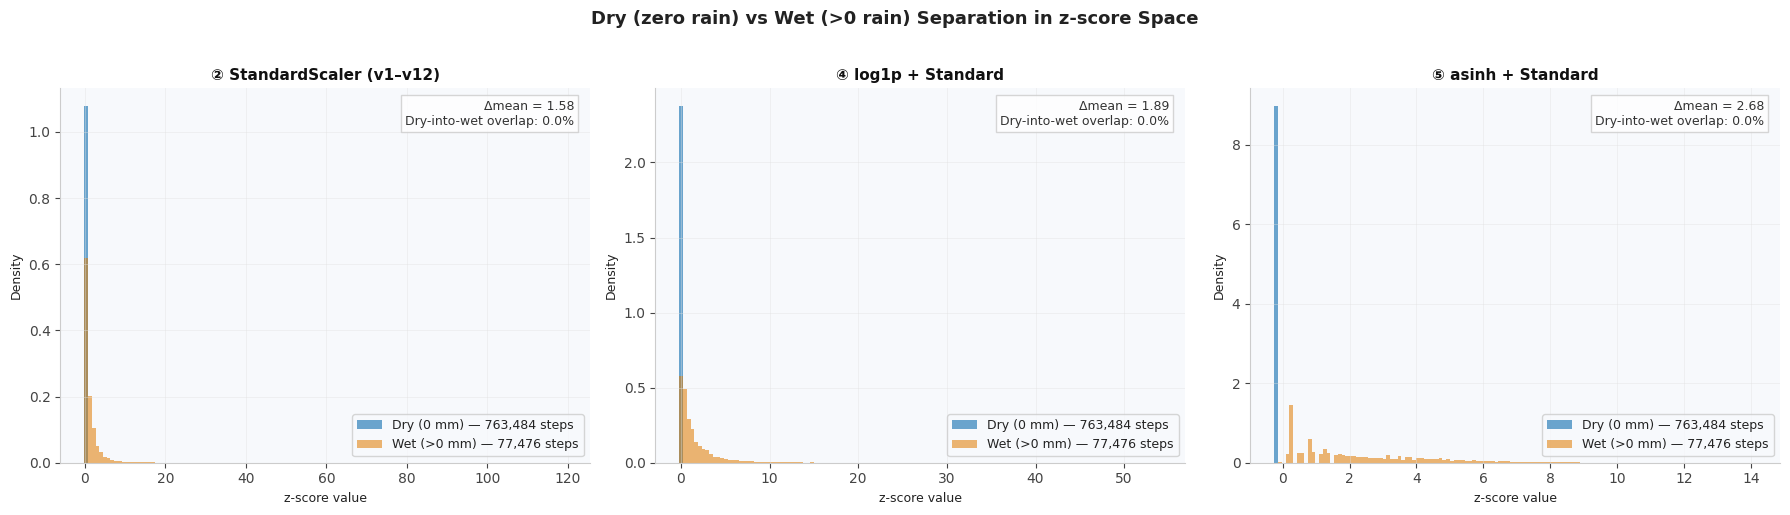

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='white')
fig.suptitle('Dry (zero rain) vs Wet (>0 rain) Separation in z-score Space',
             fontsize=13, fontweight='bold', y=1.02)

def sep_panel(ax, z, title):
    z_dry = z[~wet_mask]
    z_wet = z[wet_mask]
    lo    = min(z_dry.min(), z_wet.min())
    hi    = max(z_dry.max(), z_wet.max())
    bins  = np.linspace(lo, hi, 130)
    ax.hist(z_dry, bins=bins, alpha=0.65, color='#1f77b4',
            label=f'Dry (0 mm) — {len(z_dry):,} steps', density=True)
    ax.hist(z_wet, bins=bins, alpha=0.55, color='#e07b00',
            label=f'Wet (>0 mm) — {len(z_wet):,} steps', density=True)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('z-score value', fontsize=9)
    ax.set_ylabel('Density', fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.4)
    # Overlap = fraction of dry steps that have z > min(wet z)
    overlap = (z_dry > z_wet.min()).mean()
    delta_mu = z_wet.mean() - z_dry.mean()
    ax.text(0.97, 0.97,
            f'Δmean = {delta_mu:.2f}\nDry-into-wet overlap: {overlap:.1%}',
            transform=ax.transAxes, fontsize=9, color='#333333',
            va='top', ha='right',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='#cccccc', pad=3))

sep_panel(axes[0], z_std, '② StandardScaler (v1–v12)')
sep_panel(axes[1], z_log, '④ log1p + Standard')
sep_panel(axes[2], z_asi, '⑤ asinh + Standard')

plt.tight_layout()
plt.show()

---
## Step 7 — Reconstruction Check

Before recommending any transform we must confirm we can **undo** it perfectly — otherwise the generated rainfall values would be wrong when we convert the model's output back to real units.

All three scalers should reconstruct with near-machine-precision errors (~1e-6 mm).  
If reconstruction error is large, that transform is not safe to use.

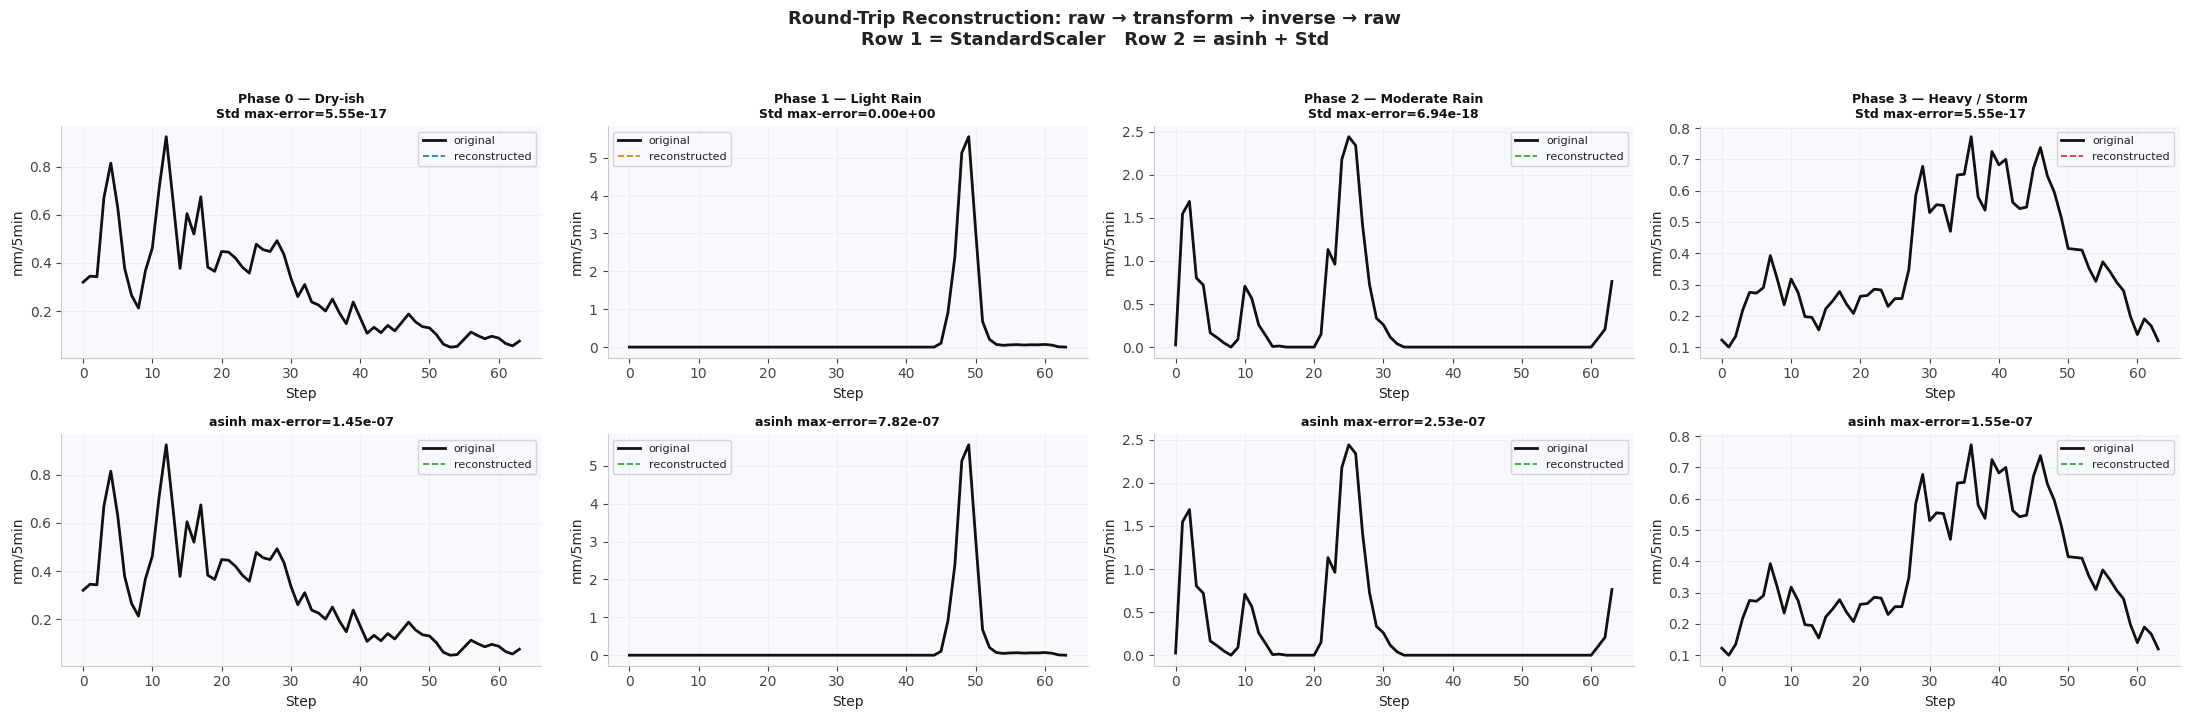


Errors should be around 1e-6 or below — safe to use.


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(22, 7), facecolor='white')
fig.suptitle('Round-Trip Reconstruction: raw → transform → inverse → raw\n'
             'Row 1 = StandardScaler   Row 2 = asinh + Std',
             fontsize=13, fontweight='bold', y=1.02)

for col, phase in enumerate([0, 1, 2, 3]):
    raw  = sequences[phase]['raw']
    t    = np.arange(SEQ_LEN)
    c    = PHASE_COLORS[phase]

    # Row 0: Standard scaler round-trip
    recon_std = std_scaler.inverse_transform(std_scaler.transform(raw.reshape(-1,1))).ravel()
    err_std   = np.abs(raw - recon_std).max()
    ax = axes[0, col]
    ax.plot(t, raw,       color='#111111', linewidth=2.0, label='original', zorder=3)
    ax.plot(t, recon_std, color=c,         linewidth=1.2, linestyle='--', label='reconstructed', zorder=2)
    ax.set_title(f'{PHASE_LABELS[phase]}\nStd max-error={err_std:.2e}', fontsize=9)
    ax.set_xlabel('Step'); ax.set_ylabel('mm/5min')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.4)

    # Row 1: asinh scaler round-trip
    recon_asi = asinh_scaler.inverse_transform(asinh_scaler.transform(raw.reshape(-1,1))).ravel()
    err_asi   = np.abs(raw - recon_asi).max()
    ax = axes[1, col]
    ax.plot(t, raw,       color='#111111', linewidth=2.0, label='original', zorder=3)
    ax.plot(t, recon_asi, color='#2ca02c', linewidth=1.2, linestyle='--', label='reconstructed', zorder=2)
    ax.set_title(f'asinh max-error={err_asi:.2e}', fontsize=9)
    ax.set_xlabel('Step'); ax.set_ylabel('mm/5min')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()
print('\nErrors should be around 1e-6 or below — safe to use.')

---
## Step 8 — Summary Statistics Table

In [ ]:
from IPython.display import display

rows = []
for phase in [0, 1, 2, 3]:
    raw = sequences[phase]['raw']
    for name, z in [
        ('② Standard (current)', sequences[phase]['standard']),
        ('④ log1p + Std',        sequences[phase]['log1p']),
        ('⑤ asinh + Std',        sequences[phase]['asinh']),
    ]:
        dry_z  = float(z[raw == 0].mean()) if (raw == 0).any() else float('nan')
        rows.append({
            'Phase':       PHASE_LABELS[phase],
            'Transform':   name,
            'z_min':       round(float(z.min()), 2),
            'z_max':       round(float(z.max()), 2),
            'z_mean':      round(float(z.mean()), 3),
            'z_dry (0mm)': round(dry_z, 3),
            'n_wet':       int((raw > 0).sum()),
            'raw_peak_mm': round(float(raw.max()), 4),
        })

df_summary = pd.DataFrame(rows)
display(df_summary)

,Phase,Transform,z_min,z_max,z_mean,z_dry (0mm),n_wet,raw_peak_mm
0,Phase 0 — Dry-ish,② Standard (current),0.93,19.78,6.366,NaN,64,0.9250
1,Phase 0 — Dry-ish,④ log1p + Std,1.24,18.75,7.114,NaN,64,0.9250
2,Phase 0 — Dry-ish,⑤ asinh + Std,2.64,9.66,6.251,NaN,64,0.9250
3,Phase 1 — Light Rain,② Standard (current),-0.15,119.51,6.107,-0.145,18,5.5550
4,Phase 1 — Light Rain,④ log1p + Std,-0.17,54.15,3.571,-0.174,18,5.5550
5,Phase 1 — Light Rain,⑤ asinh + Std,-0.25,14.14,1.523,-0.247,18,5.5550
6,Phase 2 — Moderate Rain,② Standard (current),-0.15,52.47,6.600,-0.145,30,2.4425
7,Phase 2 — Moderate Rain,④ log1p + Std,-0.17,35.54,5.668,-0.174,30,2.4425
8,Phase 2 — Moderate Rain,⑤ asinh + Std,-0.25,12.09,3.122,-0.247,30,2.4425
9,Phase 3 — Heavy / Storm,② Standard (current),2.01,16.49,8.060,NaN,64,0.7725


---
## Final Verdict & Recommendations

### How our model (EDM) differs from basic DDPM

Our model uses **EDM** (Elucidating the Design Space of Diffusion Models, Karras et al. 2022) — not DDPM.  
EDM is more sophisticated and has a built-in mechanism to balance learning across different noise levels.  
It is worth understanding exactly what EDM does — and what it *does not* fix — before choosing a preprocessing strategy.

#### What EDM does: balance across *noise levels*

EDM trains by sampling a noise level σ from a log-normal distribution, adding noise to the image,
and asking the network to denoise it. The loss at each noise level is multiplied by a weight λ(σ):

```
λ(σ) = (σ² + σ_data²) / (σ · σ_data)²
```

This weight ensures every noise level σ contributes roughly equally to the total loss.  
**In other words: EDM stops the model from ignoring either very fine detail (small σ) or coarse structure (large σ).**  
This is one of EDM's key improvements over DDPM.

#### What EDM does *not* fix: within-noise-level tail dominance

The λ(σ) weighting balances across noise *levels* — but **within a single noise level**, the loss is still plain MSE averaged over all pixels:

```
L(σ) = λ(σ) × mean_pixels[ (predicted_pixel − true_pixel)² ]
```

If one pixel has z = 120 (storm peak) and all others have z ≈ −0.15 (dry), then at any given σ:

```
(120)² / (0.15)² ≈ 640,000× more gradient from the storm pixel than from a single dry pixel
```

The storm pixel still completely dominates within each noise level — **EDM's λ(σ) does not protect against extreme pixel values**.

With asinh (z_max ≈ 14):

```
(14)² / (0.25)² ≈ 3,136× more gradient from the peak → still biased, but ~200× less extreme
```

#### An additional concern: σ_data mismatch

EDM's preconditioning formulas assume data has standard deviation roughly equal to `σ_data`.
In our code (`ImagenFew.py`) this is hardcoded to **σ_data = 0.5**.  
But both StandardScaler and asinh+Std produce data with std ≈ 1.0 — a 2× mismatch.  
This mismatch affects both transforms equally and is a **separate issue worth fixing in v13**
by setting `sigma_data = 1.0` in `ImagenFew.py`. It does not change which transform is better.

---

### Summary table

| | ② StandardScaler (v1–v12) | ④ log1p + Std | ⑤ asinh + Std (proposed) |
|--|---------------------------|--------------|---------------------------|
| **Tail z_max (training set)** | ~120 | ~55 | **~14** |
| **Tail compression vs Standard** | — | ~2× | **~8–9×** |
| **Within-σ gradient ratio (peak vs dry)** | ~640,000× | ~90,000× | **~3,100×** |
| **EDM λ(σ) balances this?** | ✗ (balances σ levels only) | ✗ | ✗ |
| **Dry-step z-value** | z ≈ −0.145 (well-defined) | **z = dry ≡ lightest rain** ← fatal | z ≈ −0.247 (well-defined) |
| **Dry/wet separability** | ✓ | ✗ | ✓ |
| **Invertible?** | ✓ | ✓ | ✓ |
| **Verdict** | ⚠️ Tail dominates within-σ MSE | ✗ Model can't learn zero-rainfall | ✓ **Best choice** |

---

### Recommendation: move to `asinh` for v13+

**What asinh does in plain words:**  
For small rainfall (x ≪ 0.035 mm/5min), `asinh(x/s) ≈ x/s` — nearly linear, so light rain keeps its relative resolution.  
For large rainfall (x ≫ 0.035 mm), `asinh(x/s) ≈ log(2x/s)` — logarithmic compression of storm peaks.  
The scale `s = 0.035` is set to the **median of all wet timesteps**, so the transition happens at a physically meaningful intensity.

**What this means for EDM training specifically:**
1. **Within every noise level σ**, storm peaks contribute ~200× less relative gradient than with StandardScaler.  
   EDM's λ(σ) still balances across noise levels as before — asinh just makes the *data range* more reasonable.
2. **Dry steps stay at a unique z-value** (z ≈ −0.247), cleanly below wet steps.  
   The model can still learn to 'switch off' rain — unlike log1p.
3. **Light rain keeps its resolution** — the linear region of asinh is preserved for x < s.
4. **The 8×8 delay-embedded image** becomes more balanced — a spread of blue tones rather than white + one dark spike.  
   This gives every U-Net convolution kernel a useful gradient, not just those near the storm pixel.

**Bonus fix for v13:** Also set `sigma_data = 1.0` in `ImagenFew.py`  
to match the actual std of the preprocessed data (both Standard and asinh output std ≈ 1.0).  
This fixes the EDM preconditioning mismatch independently of the transform choice.

5. **Preserves global dataset-wide scaling:** Like `StandardScaler`, `AsinhScaler` is fitted once on the entire training set column, saved to `scaler.pkl`, and applied globally. It requires zero sequence-level parameters, handles all-dry sequences seamlessly without $0/0$ division, and is 100% invertible at generation time.

**How to enable asinh:** in `regime_training/config_v13.yaml`, set:
```yaml
data_transform: asinh
asinh_scale: 0.035
```
The `AsinhScaler` is already implemented in `regime_training/transforms.py` and fully supported by `RegimeDataset`.